# **Code for Chapter 1**

In [ ]:
import random
from abc import ABC
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class TVShowGame:
  def __init__(self):

    self.action_space = ["D1", "D2", "D3", "D4"]

  def get_reward(self, action):
    if action=="D1":
      return random.choice([0, 2, 3, 4])
    if action=="D2":
      return random.choice([1, 3, 6])
    if action=="D3":
      return random.choice([0, 5, 15])
    if action=="D4":
      return -5


class Policy:
  def __init__(self, eps:float, env:TVShowGame):

    self.eps = eps
    self.env = env
    self.actions_value = [0, 0, 0, 0] # mean reward of D1, D2, D3, D4
    self.reward_obtained = {action: [] for action in env.action_space}
    self.episode_action_value = [[] for i in range(len(self.actions_value))]
    self.action_count = {action: [] for action in env.action_space}

  def reset(self):
    self.actions_value = [0, 0, 0, 0] # mean reward of D1, D2, D3, D4
    self.reward_obtained = {action: [] for action in env.action_space}
    self.episode_action_value = [[] for i in range(len(self.actions_value))]
    self.action_count = {action: [] for action in env.action_space}

  def get_action(self)->str:

    if random.random()<=self.eps:
      return random.choice(self.env.action_space)
    else:
      max_value = max(self.actions_value)
      action = self.actions_value.index(max_value)

      return self.env.action_space[action]

  def get_action_idx(self, action)->str:

    idx = self.env.action_space.index(action)
    return idx

  def update_reward(self, action, reward):

    return self.reward_obtained[action].append(reward)

  def update_action_value(self)->None:

    for action, saved_rewards in self.reward_obtained.items():
      if len(saved_rewards)>0:
        mean_reward = sum(saved_rewards)/(len(saved_rewards))
        action_idx = self.get_action_idx(action)
        self.actions_value[action_idx] = mean_reward
        self.episode_action_value[action_idx].append(mean_reward)

  def run(self, max_step=60):
    rewards = []
    reward = 0
    for step in range(max_step):
      action = self.get_action()
      rew = self.env.get_reward(action)
      self.update_reward(action, rew)
      self.update_action_value()
      self.action_count[action].append(action)
      reward += rew
      rewards.append(reward)

    return rewards, reward

In [ ]:
num_runs = 1000
runs_rewards = [[] for i in range(num_runs)]
runs_reward_total = [[] for i in range(num_runs)]
runs_action_value = [[] for i in range(num_runs)]
runs_action_count_per_run = [[] for i in range(num_runs)]
runs_last_action_value = [[] for i in range(4)]
for i in range(num_runs):
  random.seed(random.randint(1, 100))
  env = TVShowGame()
  p2 = Policy(eps=0.1, env=env)
  p2.reset()
  rewards, reward_total = p2.run(60)
  runs_rewards[i] = rewards
  runs_reward_total[i] = reward_total
  runs_action_value[i] = p2.episode_action_value

  action_counts = [len(p2.action_count[action]) for action in env.action_space]
  runs_action_count_per_run[i] = action_counts

  for i in range(4):
    runs_last_action_value[i].append(p2.actions_value[i])


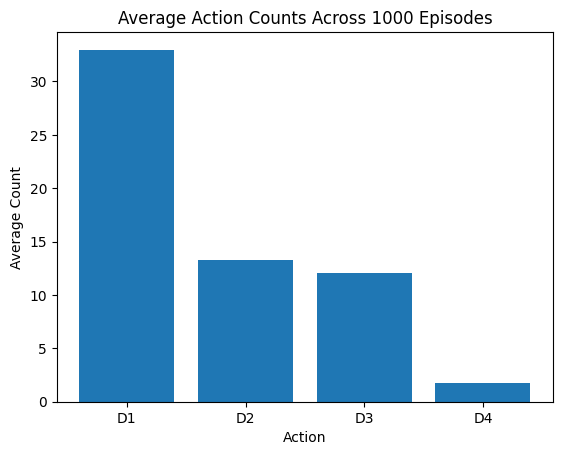

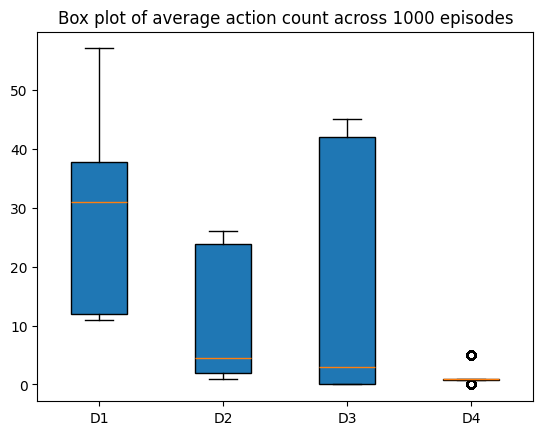

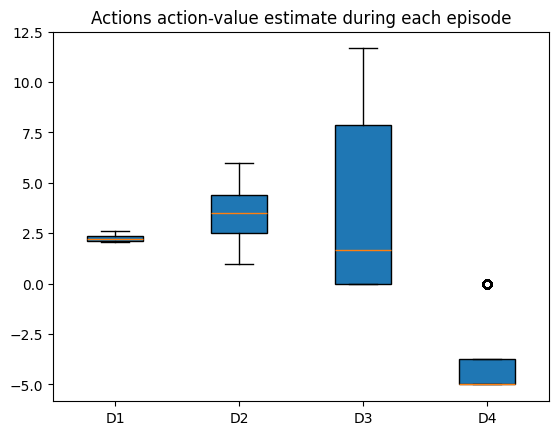

In [5]:
mean_rewards = np.array(runs_rewards).mean(axis=0)
std_rewards = np.array(runs_rewards).std(axis=0)
means_action_values = [[] for _ in range(len(runs_action_value))]

for idx, run_data in enumerate(runs_action_value):
  means = []

  # Ensure action_history is not empty before calculating mean
  for action_history in run_data:
    if action_history: # Check if list is not empty
        means.append(np.mean(action_history))
    else:
        means.append(0)

  means_action_values[idx] = means

num_actions = len(env.action_space) # Should be 4


# Calculate the average counts for each action across all runs
average_action_counts = np.array(runs_action_count_per_run).mean(axis=0)
action_labels = env.action_space # Using the action space from the last env

plt.figure()
plt.bar(action_labels, average_action_counts)
plt.title(f"Average Action Counts Across {num_runs} Episodes")
plt.xlabel("Action")
plt.ylabel("Average Count")
plt.show()

# Prepare data for boxplot: Each inner list contains all counts for a single action across all runs
plt.figure()
data_for_boxplot = []
for action_idx in range(len(env.action_space)):
    action_data_across_runs = [run_counts[action_idx] for run_counts in runs_action_count_per_run]
    data_for_boxplot.append(action_data_across_runs)

# Now, create the boxplot with the correctly structured data
bplot = plt.boxplot(data_for_boxplot,
                    patch_artist=True,  # fill with color
                    tick_labels=action_labels)  # will be used to label x-ticks
plt.title("Box plot of average action count across 1000 episodes")

plt.figure()
# plot action values for all runs
bplot = plt.boxplot(runs_last_action_value,
                    patch_artist=True,  # fill with color
                    tick_labels=action_labels)  # will be used to label x-ticks
plt.title("Actions action-value estimate during each episode")

plt.show()

/tmp/ipython-input-1492445881.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


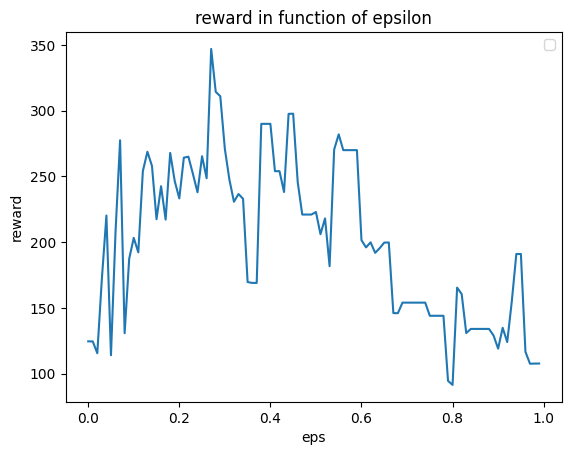

In [ ]:
# This for the last experiment where we tested the
# total reward obtained in function of epsilon

list_eps = 0.01*np.arange(0, 100)
size = len(list_eps)
list_reward_total = [[] for i in range(size)]

for idx, eps in enumerate(list_eps):
  means = []
  for i in range(1000):
    random.seed(random.randint(1, 100))
    env = TVShowGame()
    p2 = Policy(eps=eps, env=env)
    p2.reset()
    rewards, reward_total = p2.run(60)
    means.append(reward_total)

  list_reward_total[idx] = np.mean(means)
plt.title("total reward in function of epsilon")
plt.plot(list_eps, list_reward_total)
plt.xlabel("eps")
plt.ylabel("reward")
plt.legend()